## EDA - Прогнозирование успеваемости студентов

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder


In [20]:
data = pd.read_csv("../students.csv", sep=";")

## Исследование исходных данных

### Датасет содержит следующие поля:
1. Marital Status: 
    - 1 - single 
    - 2 – married 
    - 3 – widower 
    - 4 – divorced 
    - 5 – facto union 
    - 6 – legally separated
2. Application mode:
    - 1 - 1st phase - general contingent 
    - 2 - Ordinance No. 612/93 
    - 5 - 1st phase - special contingent (Azores Island) 
    - 7 - Holders of other higher courses 
    - 10 - Ordinance No. 854-B/99 
    - 15 - International student (bachelor) 
    - 16 - 1st phase - special contingent (Madeira Island) 
    - 17 - 2nd phase - general contingent 
    - 18 - 3rd phase - general contingent 
    - 26 - Ordinance No. 533-A/99, item b2 (Different Plan) 
    - 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 
    - 39 - Over 23 years old 
    - 42 - Transfer 
    - 43 - Change of course 
    - 44 - Technological specialization diploma holders 
    - 51 - Change of institution/course 
    - 53 - Short cycle diploma holders 
    - 57 - Change of institution/course (International)
3. Application order:
    - between 0 - first choice; and 9 last choice
4. Course:
    - 33 - Biofuel Production Technologies 
    - 171 - Animation and Multimedia Design 
    - 8014 - Social Service (evening attendance) 
    - 9003 - Agronomy 
    - 9070 - Communication Design 
    - 9085 - Veterinary Nursing 
    - 9119 - Informatics Engineering 
    - 9130 - Equinculture 
    - 9147 - Management 
    - 9238 - Social Service 
    - 9254 - Tourism 
    - 9500 - Nursing 
    - 9556 - Oral Hygiene 
    - 9670 - Advertising and Marketing Management 
    - 9773 - Journalism and Communication 
    - 9853 - Basic Education 
    - 9991 - Management (evening attendance)	
5. Daytime/evening attendance:
    - 1 – daytime 
    - 0 - evening
6. Previous qualification:
    - 1 - Secondary education 
    - 2 - Higher education - bachelor's degree 
    - 3 - Higher education - degree 
    - 4 - Higher education - master's 
    - 5 - Higher education - doctorate 
    - 6 - Frequency of higher education 
    - 9 - 12th year of schooling - not completed 
    - 10 - 11th year of schooling - not completed 
    - 12 - Other - 11th year of schooling 
    - 14 - 10th year of schooling 
    - 15 - 10th year of schooling - not completed 
    - 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 
    - 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 42 - Professional higher technical course 
    - 43 - Higher education - master (2nd cycle)
7. Previous qualification (grade):
    - Grade of previous qualification (between 0 and 200)
8. Nacionality: 
    - 1 - Portuguese; 
    - 2 - German; 
    - 6 - Spanish; 
    - 11 - Italian; 
    - 13 - Dutch; 
    - 14 - English; 
    - 17 - Lithuanian; 
    - 21 - Angolan; 
    - 22 - Cape Verdean; 
    - 24 - Guinean; 
    - 25 - Mozambican; 
    - 26 - Santomean; 
    - 32 - Turkish; 
    - 41 - Brazilian; 
    - 62 - Romanian; 
    - 100 - Moldova (Republic of); 
    - 101 - Mexican; 
    - 103 - Ukrainian; 
    - 105 - Russian; 
    - 108 - Cuban; 
    - 109 - Colombian
9.  Mother's qualification: 
    - 1 - Secondary Education - 12th Year of Schooling or Eq. 
    - 2 - Higher Education - Bachelor's Degree 
    - 3 - Higher Education - Degree 
    - 4 - Higher Education - Master's 
    - 5 - Higher Education - Doctorate 
    - 6 - Frequency of Higher Education 
    - 9 - 12th Year of Schooling - Not Completed 
    - 10 - 11th Year of Schooling - Not Completed 
    - 11 - 7th Year (Old) 
    - 12 - Other - 11th Year of Schooling 
    - 14 - 10th Year of Schooling 
    - 18 - General commerce course 
    - 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 
    - 22 - Technical-professional course 
    - 26 - 7th year of schooling 
    - 27 - 2nd cycle of the general high school course 
    - 29 - 9th Year of Schooling - Not Completed 
    - 30 - 8th year of schooling 
    - 34 - Unknown 
    - 35 - Can't read or write 
    - 36 - Can read without having a 4th year of schooling 
    - 37 - Basic education 1st cycle (4th/5th year) or equiv. 
    - 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 41 - Specialized higher studies course 
    - 42 - Professional higher technical course 
    - 43 - Higher Education - Master (2nd cycle) 
    - 44 - Higher Education - Doctorate (3rd cycle)
10. Father's qualification: 
    - 1 - Secondary Education - 12th Year of Schooling or Eq. 
    - 2 - Higher Education - Bachelor's Degree 
    - 3 - Higher Education - Degree 
    - 4 - Higher Education - Master's 
    - 5 - Higher Education - Doctorate 
    - 6 - Frequency of Higher Education 
    - 9 - 12th Year of Schooling - Not Completed 
    - 10 - 11th Year of Schooling - Not Completed 
    - 11 - 7th Year (Old) 
    - 12 - Other - 11th Year of Schooling 
    - 13 - 2nd year complementary high school course 
    - 14 - 10th Year of Schooling 
    - 18 - General commerce course 
    - 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 
    - 20 - Complementary High School Course 
    - 22 - Technical-professional course 
    - 25 - Complementary High School Course - not concluded 
    - 26 - 7th year of schooling 
    - 27 - 2nd cycle of the general high school course 
    - 29 - 9th Year of Schooling - Not Completed 
    - 30 - 8th year of schooling 
    - 31 - General Course of Administration and Commerce 
    - 33 - Supplementary Accounting and Administration 
    - 34 - Unknown 35 - Can't read or write 
    - 36 - Can read without having a 4th year of schooling 
    - 37 - Basic education 1st cycle (4th/5th year) or equiv. 
    - 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 41 - Specialized higher studies course 
    - 42 - Professional higher technical course 
    - 43 - Higher Education - Master (2nd cycle) 
    - 44 - Higher Education - Doctorate (3rd cycle)
11. Mother's occupation:
    - 0 - Student 
    - 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
    - 2 - Specialists in Intellectual and Scientific Activities 
    - 3 - Intermediate Level Technicians and Professions 
    - 4 - Administrative staff 
    - 5 - Personal Services, Security and Safety Workers and Sellers 
    - 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
    - 7 - Skilled Workers in Industry, Construction and Craftsmen 
    - 8 - Installation and Machine Operators and Assembly Workers 
    - 9 - Unskilled Workers 
    - 10 - Armed Forces Professions 
    - 90 - Other Situation 
    - 99 - (blank) 
    - 122 - Health professionals 
    - 123 - teachers 
    - 125 - Specialists in information and communication technologies (ICT) 
    - 131 - Intermediate level science and engineering technicians and professions 
    - 132 - Technicians and professionals, of intermediate level of health 
    - 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 
    - 141 - Office workers, secretaries in general and data processing operators 
    - 143 - Data, accounting, statistical, financial services and registry-related operators 
    - 144 - Other administrative support staff 
    - 151 - personal service workers 
    - 152 - sellers 
    - 153 - Personal care workers and the like 
    - 171 - Skilled construction workers and the like, except electricians 
    - 173 - Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like 
    - 175 - Workers in food processing, woodworking, clothing and other industries and crafts 
    - 191 - cleaning workers 
    - 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 
    - 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 
    - 194 - Meal preparation assistants
12. Father's occupation:
    - 0 - Student 
    - 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
    - 2 - Specialists in Intellectual and Scientific Activities 
    - 3 - Intermediate Level Technicians and Professions 
    - 4 - Administrative staff 
    - 5 - Personal Services, Security and Safety Workers and Sellers 
    - 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
    - 7 - Skilled Workers in Industry, Construction and Craftsmen 
    - 8 - Installation and Machine Operators and Assembly Workers 
    - 9 - Unskilled Workers 10 - Armed Forces Professions 
    - 90 - Other Situation 
    - 99 - (blank) 
    - 101 - Armed Forces Officers 
    - 102 - Armed Forces Sergeants 
    - 103 - Other Armed Forces personnel 
    - 112 - Directors of administrative and commercial services 
    - 114 - Hotel, catering, trade and other services directors 
    - 121 - Specialists in the physical sciences, mathematics, engineering and related techniques 
    - 122 - Health professionals 
    - 123 - teachers 
    - 124 - Specialists in finance, accounting, administrative organization, public and commercial relations 
    - 131 - Intermediate level science and engineering technicians and professions 
    - 132 - Technicians and professionals, of intermediate level of health 
    - 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 
    - 135 - Information and communication technology technicians 
    - 141 - Office workers, secretaries in general and data processing operators 
    - 143 - Data, accounting, statistical, financial services and registry-related operators 
    - 144 - Other administrative support staff 
    - 151 - personal service workers 
    - 152 - sellers 
    - 153 - Personal care workers and the like 
    - 154 - Protection and security services personnel 
    - 161 - Market-oriented farmers and skilled agricultural and animal production workers 
    - 163 - Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence 
    - 171 - Skilled construction workers and the like, except electricians 
    - 172 - Skilled workers in metallurgy, metalworking and similar 
    - 174 - Skilled workers in electricity and electronics 
    - 175 - Workers in food processing, woodworking, clothing and other industries and crafts 
    - 181 - Fixed plant and machine operators 
    - 182 - assembly workers 
    - 183 - Vehicle drivers and mobile equipment operators 
    - 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 
    - 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 
    - 194 - Meal preparation assistants 
    - 195 - Street vendors (except food) and street service providers

13. Admission grade:
    - Admission grade (between 0 and 200)
14. Displaced: 
    - 1 – yes 
    - 0 – no
15. Educational special needs:
    - 1 – yes 
    - 0 – no
16. Debtor:
    - 1 – yes 
    - 0 – no
17. Tuition fees up to date:
    - 1 – yes 
    - 0 – no
18. Gender:
    - 1 – male 
    - 0 – female
19. Scholarship holder:
    - 1 – yes 
    - 0 – no
20. Age at enrollment
    - Age of studend at enrollment
21. International
    - 1 – yes 
    - 0 – no
22. Curricular units 1st sem (credited)
    - Number of curricular units credited in the 1st semester
23. Curricular units 1st sem (enrolled)
    - Number of curricular units enrolled in the 1st semester
24. Curricular units 1st sem (evaluations)
    - Number of evaluations to curricular units in the 1st semester
25. Curricular units 1st sem (approved)
    - Number of curricular units approved in the 1st semester
26. Curricular units 1st sem (grade):
    - Grade average in the 1st semester (between 0 and 20)
27. Curricular units 1st sem (without evaluations):
    - Number of curricular units without evalutions in the 1st semester
28. Curricular units 2nd sem (credited):
    - Number of curricular units credited in the 2nd semester
29. Curricular units 2nd sem (enrolled):
    - Number of curricular units enrolled in the 2nd semester
30. Curricular units 2nd sem (evaluations):
    - Number of evaluations to curricular units in the 2nd semester
31. Curricular units 2nd sem (approved):
    - Number of curricular units approved in the 2nd semester
32. Curricular units 2nd sem (grade):
    - Grade average in the 2nd semester (between 0 and 20)
33. Curricular units 2nd sem (without evaluations):
    - Number of curricular units without evalutions in the 1st semester
34. Unemployment rate:
    - Unemployment rate (%)
35. Inflation rate:
    - Inflation rate (%)
36. GDP:
    - GDP
37. Target:
    - Target. The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [22]:
data.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [23]:
data.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

### Из выводов выше мы видим:
- датасет совсем не большой всего 4424 случая
- данные уже хорошо подготовленны, почти все данные кроме target имеют числовое представление
- Осталось проверить те столбцы где данные float на возможность перевести их в int без потери дробной части

## 2. Визуальный анализ данных


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/feedachyou/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


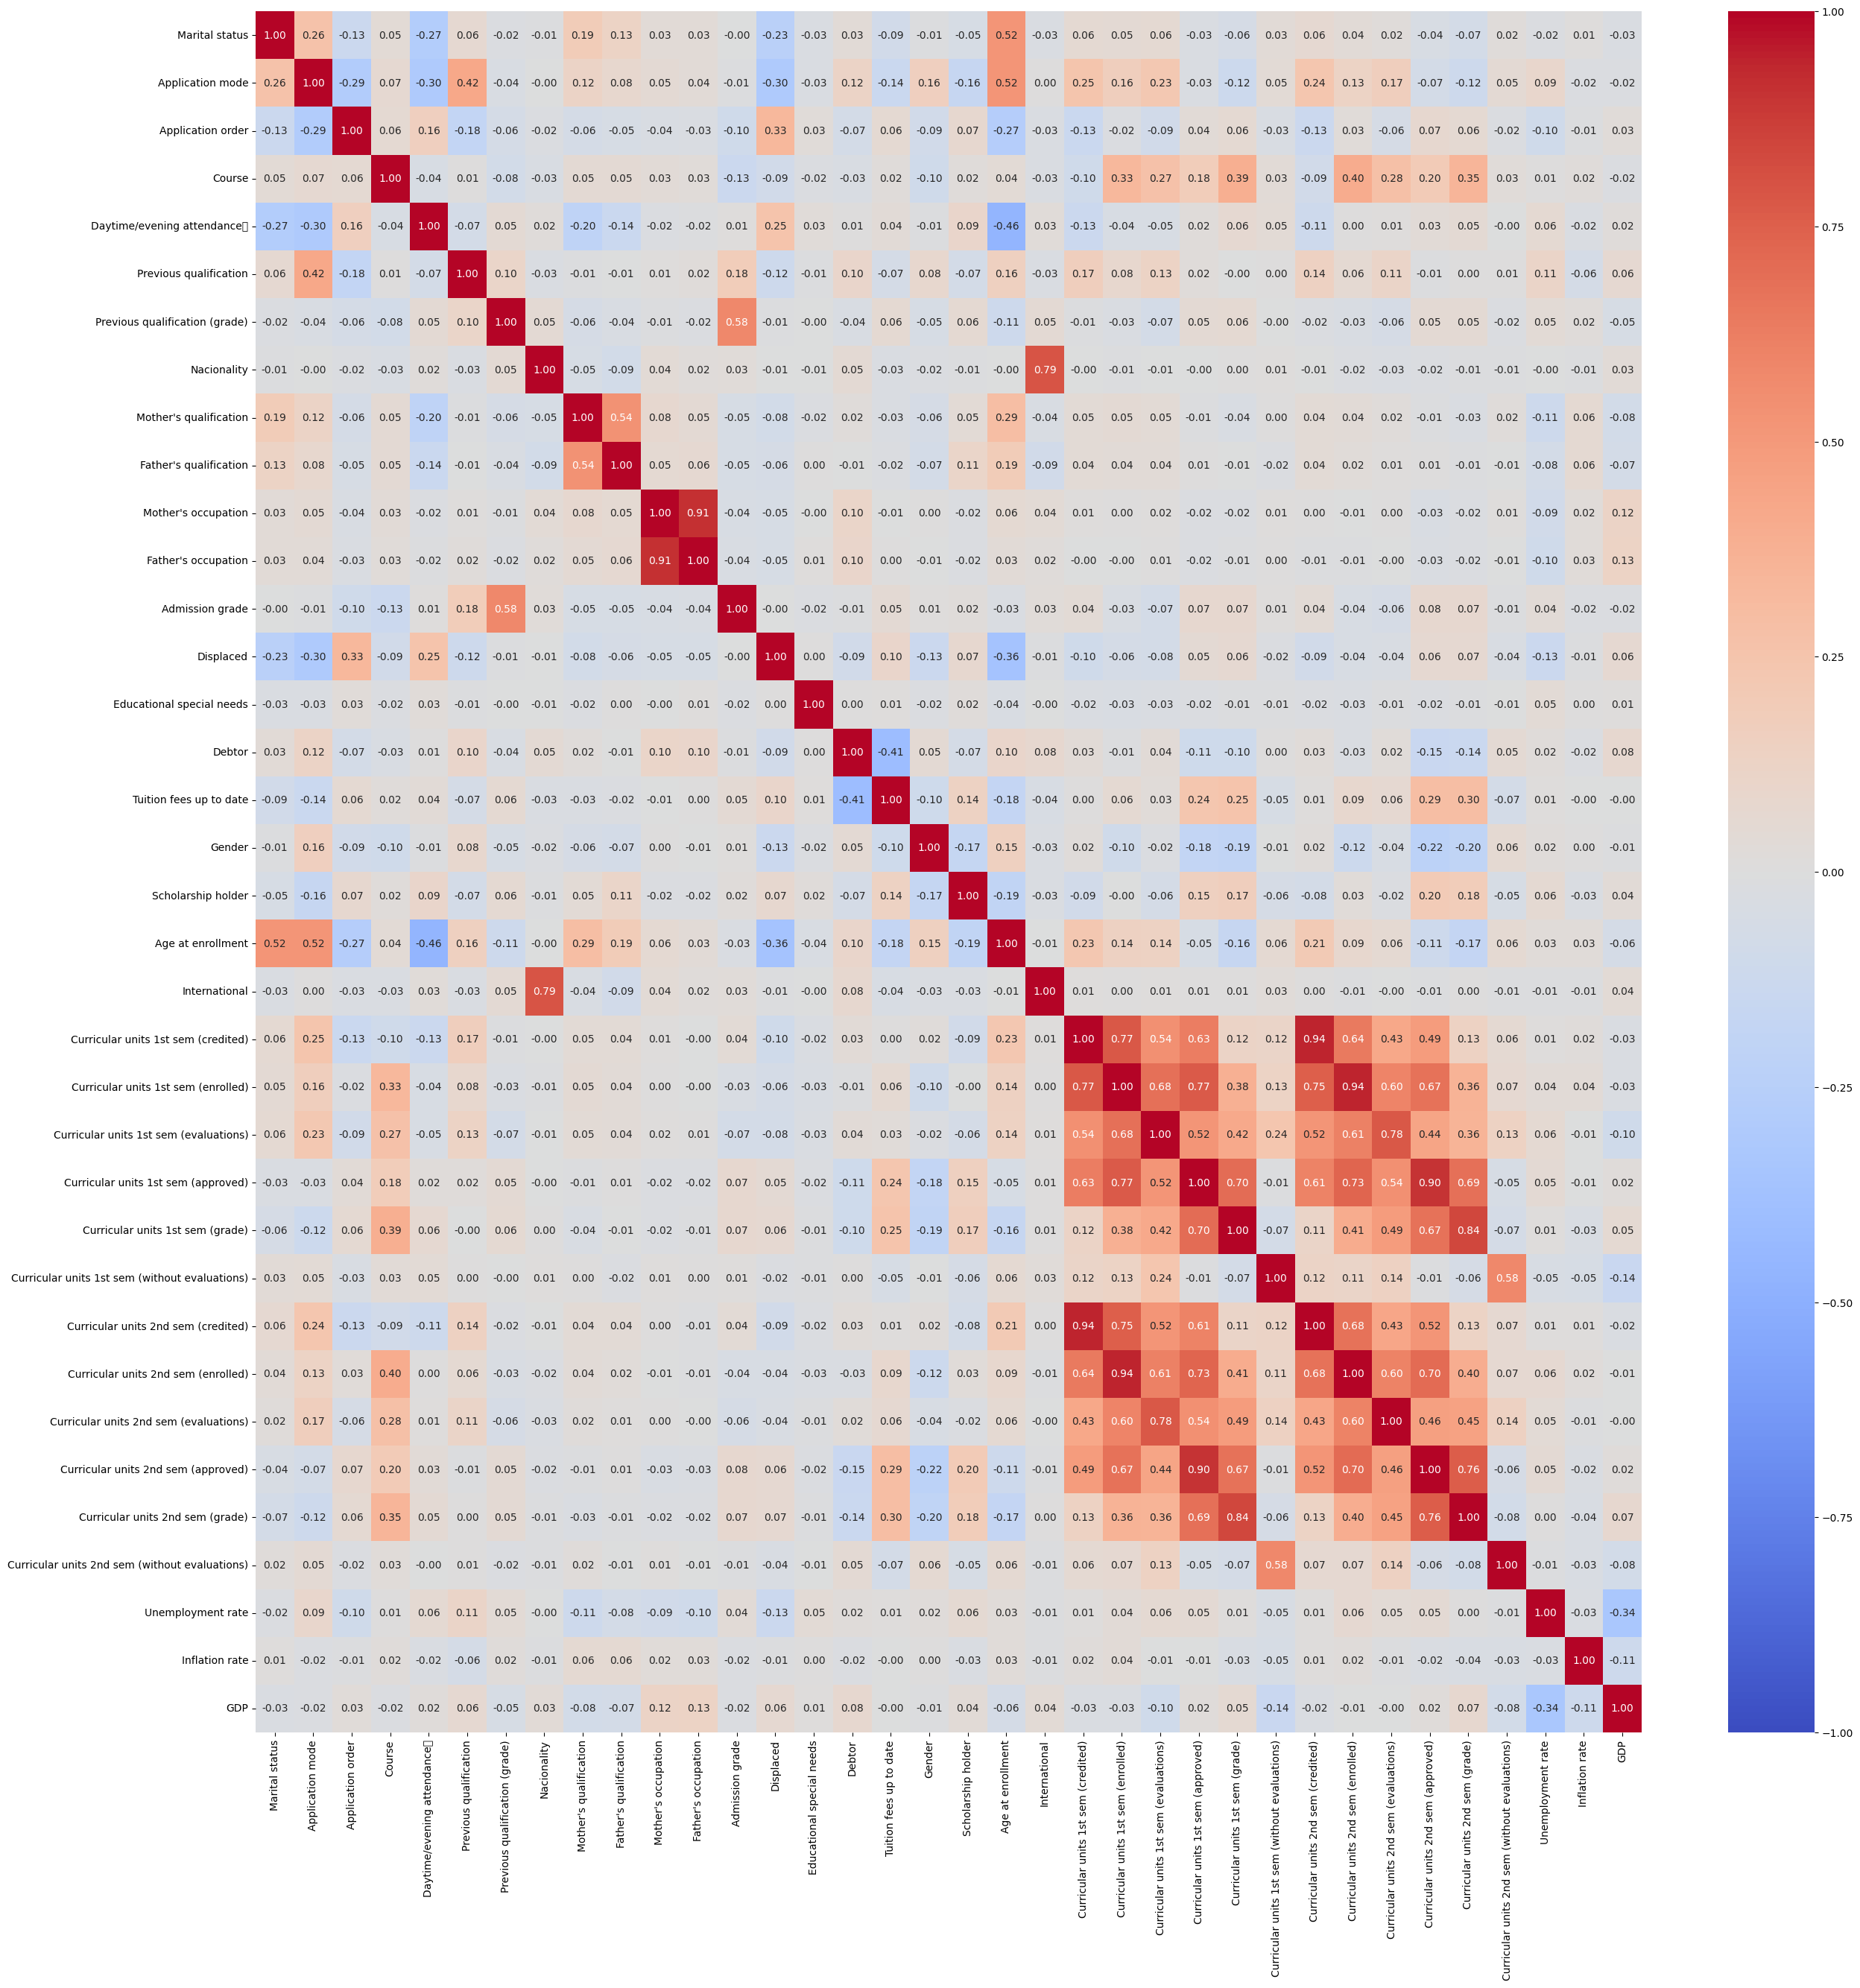

In [24]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(30, 30))
sns.heatmap(
    corr_matrix, 
    annot=True,     # Пишем значения внутри ячеек
    cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
    fmt=".2f",      # Формат чисел (2 знака после запятой)
    vmin=-1, vmax=1 # Фиксируем границы цветов (от -1 до 1)
)
plt.show()

### Из тепловой карты мы видим:
- большинство признаков слабо свящанны друг с другом
- нормальную связь имеют признаки семейного статуса и возраста, что очень логично
- национальность и международность обучения
- сильная зависимость есть у признаков, которые относятся к оценкам и предметам за семестры.

array([[<Axes: title={'center': 'Marital status'}>,
        <Axes: title={'center': 'Application mode'}>,
        <Axes: title={'center': 'Application order'}>,
        <Axes: title={'center': 'Course'}>,
        <Axes: title={'center': 'Daytime/evening attendance\t'}>,
        <Axes: title={'center': 'Previous qualification'}>],
       [<Axes: title={'center': 'Previous qualification (grade)'}>,
        <Axes: title={'center': 'Nacionality'}>,
        <Axes: title={'center': "Mother's qualification"}>,
        <Axes: title={'center': "Father's qualification"}>,
        <Axes: title={'center': "Mother's occupation"}>,
        <Axes: title={'center': "Father's occupation"}>],
       [<Axes: title={'center': 'Admission grade'}>,
        <Axes: title={'center': 'Displaced'}>,
        <Axes: title={'center': 'Educational special needs'}>,
        <Axes: title={'center': 'Debtor'}>,
        <Axes: title={'center': 'Tuition fees up to date'}>,
        <Axes: title={'center': 'Gender'}>],
   

/Users/feedachyou/Library/Python/3.14/lib/python/site-packages/IPython/core/events.py:96: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/feedachyou/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


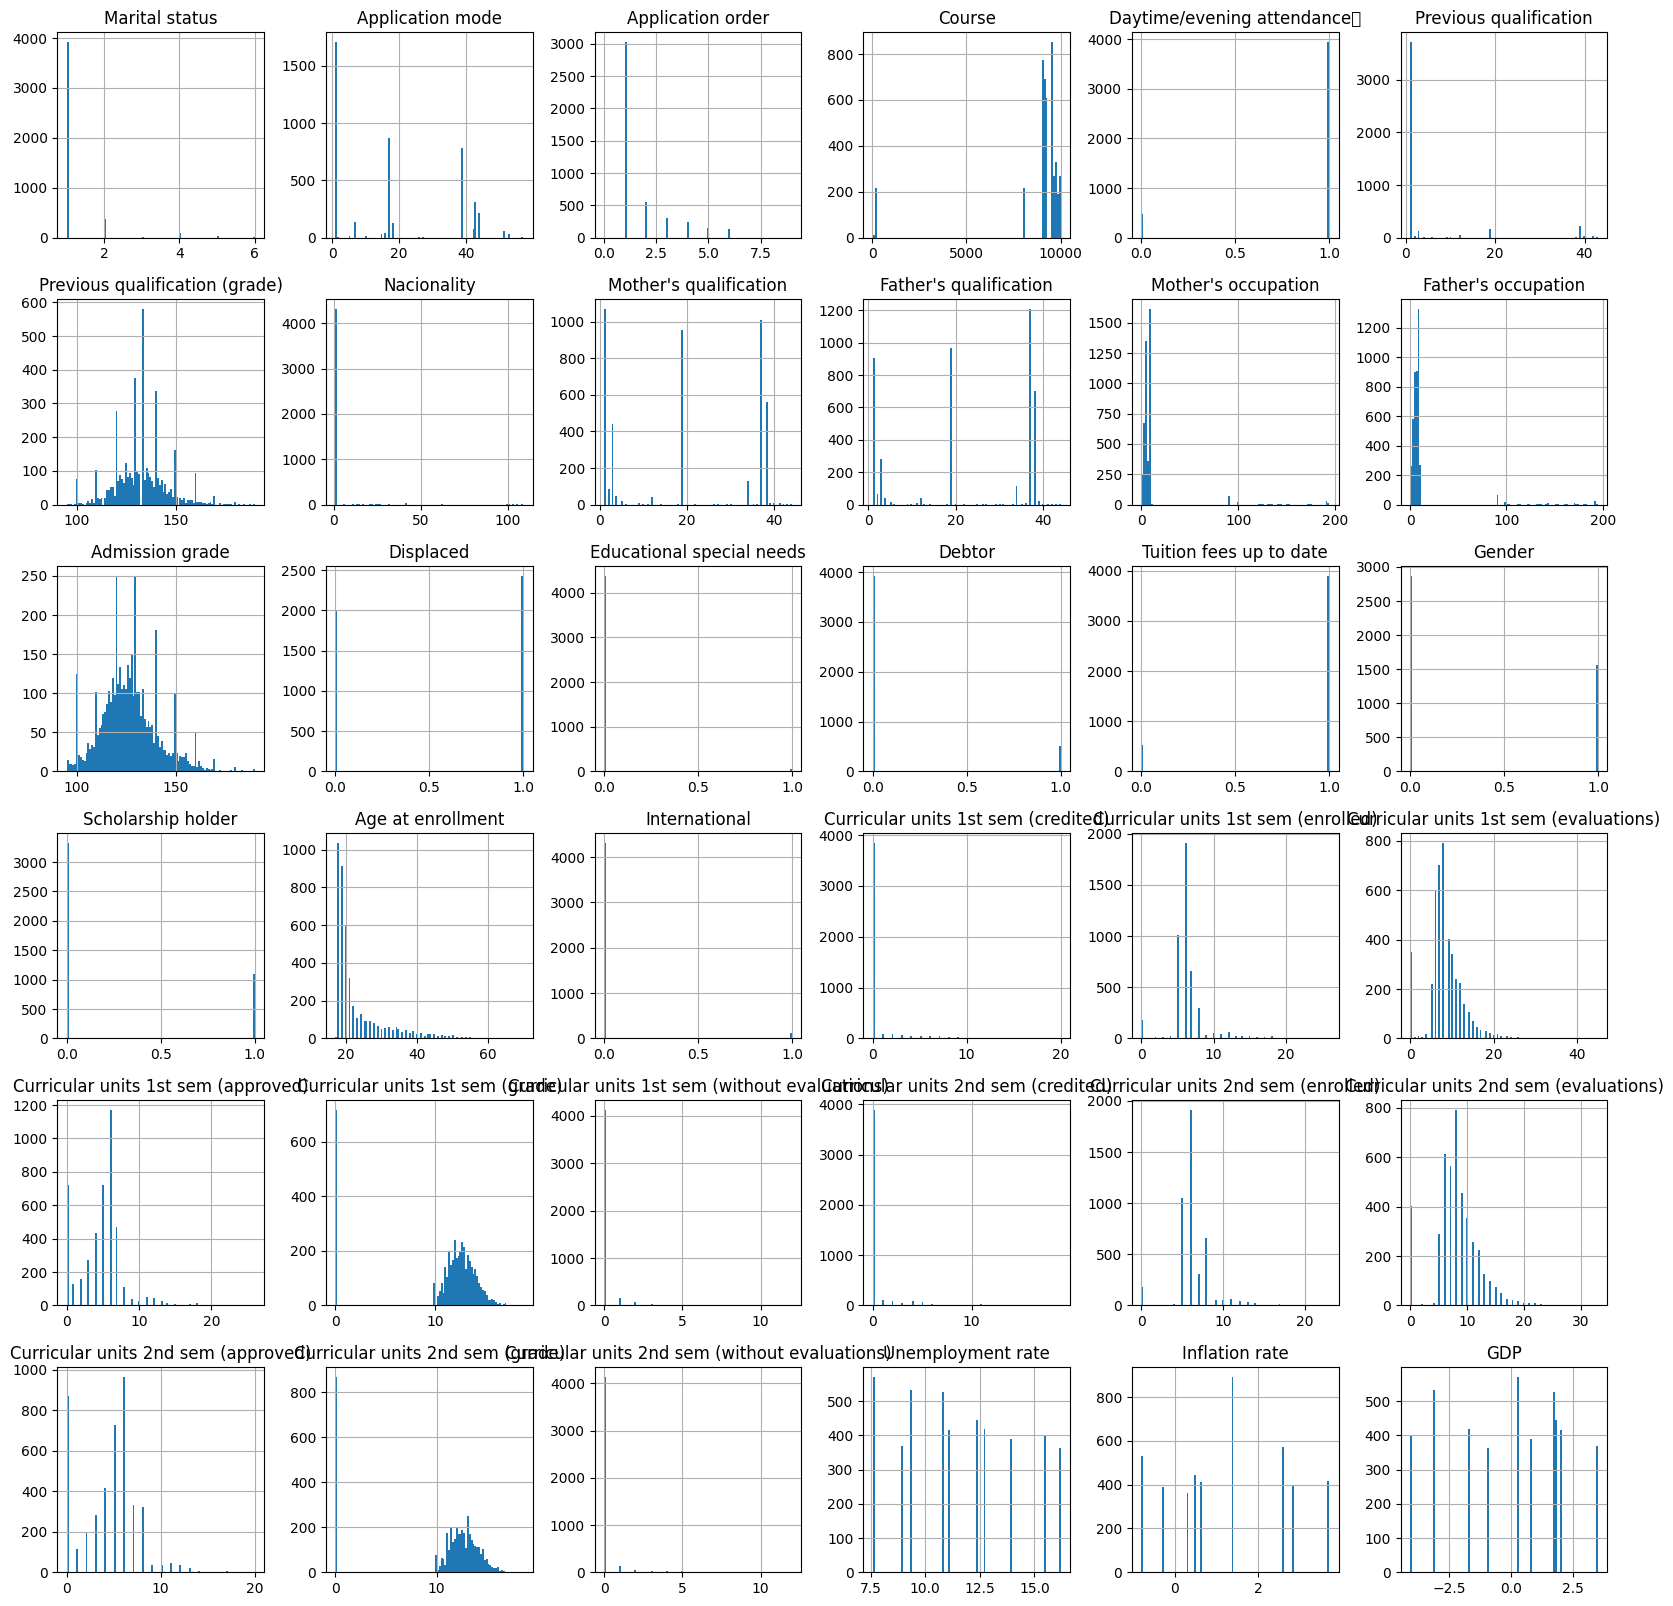

In [29]:
data.hist(figsize=[20,20], bins= 100)

### Из графиков мы видим:
- графики имеющие отношение к оценкам имеют нормальное распределение 